#**APRIORI Algorithm implementation from scratch**

The Apriori algorithm presented in this notebook is implemented entirely from scratch using python.

All core components of the algorithm were manually implemented according to the theoretical definition of the Apriori algorithm. No high-level machine learning libraries were used.

Only basic libraries such as **NumPy** were used for numerical computations, and **Matplotlib** was used solely for visualization of results.



Prepared by:


1.   Mekrez Demeke    --- UGR/5376/15
2.   Natnael Mesfin   ---- UGR/8654/15
3.   Yabqal Brook      ------UGR/2822/15
4.   Yohannes Ketema   ---UGR/6290/15
5.   Chala Gindaba ----- NSR/9838/10



## **Import Libraries and Load the Dataset**

In this step, we import the required Python libraries and load the dataset into memory.

- **NumPy** is used for efficient numerical operations.

- **Pandas** (pandas) is used to load and manipulate csv data.

- **Matplotlib** (matplotlib.pyplot) is used later for visualization.

The dataset is loaded from a CSV file into a Pandas DataFrame, which is a table-like structure with rows and columns.
Finally, we display the first few rows of the dataset to quickly inspect its structure and contents.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/sample_data/market.csv")
print(df.head())


  transaction                                      items
0       T0001    bread,cheese,milk,salt,sugar,tea,yogurt
1       T0002        apple,eggs,fish,milk,salt,sugar,tea
2       T0003    banana,bread,butter,eggs,milk,sugar,tea
3       T0004    bread,milk,onion,pasta,sugar,tea,tomato
4       T0005  banana,coffee,eggs,juice,milk,onion,sugar


### **Prepare Transactions**

- Remove rows with missing `items` using `dropna()`.
- Convert each transaction from a comma-separated string into a **set of items** to remove duplicates.
- Print total number of transactions and a sample to verify.

**Key idea:** Each transaction is now a **set of items**:

$$
\text{transaction} = \{ \text{item1, item2, …} \}
$$

This prepares the dataset for Apriori.


In [3]:
df = df.dropna(subset=['items'])
transactions = df['items'].apply(lambda x: set(x.split(','))).tolist()
print("Total transactions:", len(transactions))
print("Sample transaction:", transactions[0])

Total transactions: 500
Sample transaction: {'milk', 'bread', 'tea', 'cheese', 'salt', 'sugar', 'yogurt'}


### **Set Thresholds**

- `min_support` defines the minimum fraction of transactions an itemset must appear in to be considered **frequent**.
- `min_confidence` defines the minimum probability for a rule to be considered **strong**.


In [11]:
min_support = 0.5
min_confidence = 0.7

### **Compute Support**

- This function calculates the **support** of a given `itemset`.
- It counts how many transactions contain all items in the set and divides by the total number of transactions.
- Returns the support as a fraction between 0 and 1.

**Formula:**
$$
\text{Support}(X) = \frac{\text{Number of transactions containing } X}{\text{Total number of transactions}}
$$

where X is the itemset of interest.

In [4]:
def compute_support(itemset, transactions):
    count = 0
    for t in transactions:
        if itemset.issubset(t):
            count += 1
    return count / len(transactions)

### **Filter Frequent Itemsets**

- This function takes a list of `candidates` and keeps only the **frequent itemsets** whose support is greater than or equal to `min_support`.
- Uses `compute_support()` to calculate support for each candidate.
- Returns a dictionary where keys are frequent itemsets (as `frozenset`) and values are their support.

**Formula:**
$$
\text{frequent itemsets} = \{ X \mid \text{support}(X) \geq \text{min_support} \}
$$


In [9]:
def get_frequent_itemsets(candidates, transactions, min_support):
  frequent = {}
  for c in candidates:
    support = compute_support(c, transactions)
    if support >= min_support:
      frequent[frozenset(c)] = support
  return frequent

### **Generate Candidate Itemsets**

- Generates **candidate k-itemsets** by combining frequent (k−1)-itemsets from the previous step.
- Only keeps unions that have exactly `k` items to avoid smaller duplicates.
- Returns a set of candidate itemsets to check in the next iteration.

In [6]:
def generate_candidates(prev_frequent, k):
  prev_itemsets = list(prev_frequent.keys())
  candidates = set()
  for i in range(len(prev_itemsets)):
    for j in range(i + 1, len(prev_itemsets)):
      union = prev_itemsets[i] | prev_itemsets[j]
      if len(union) == k:
        candidates.add(union)
  return candidates

### **Run Apriori Algorithm**

- Initializes **1-item candidates** from all unique items in the transactions.
- Iteratively:
  1. Filters candidates using `get_frequent_itemsets()` to keep only frequent ones.
  2. Updates the list of all frequent itemsets.
  3. Generates new candidate itemsets of size `k+1` using `generate_candidates()`.
- Stops when no new candidates are found.
- Returns all frequent itemsets that meet the `min_support` threshold.



In [12]:
def apriori(transactions, min_support):
  items = set().union(*transactions)
  candidates = [{item} for item in items]

  frequent_itemsets = {}
  k = 1

  while candidates:
    frequent_k = get_frequent_itemsets(candidates, transactions, min_support)
    if not frequent_k:
      break

    frequent_itemsets.update(frequent_k)
    k += 1
    candidates = generate_candidates(frequent_k, k)

  return frequent_itemsets

frequent_itemsets = apriori(transactions, min_support)
print("Total frequent itemsets:", len(frequent_itemsets))

Total frequent itemsets: 7


### **Generate Association Rules**

- Generates rules from the frequent itemsets.
- For each itemset with 2 or more items:
  1. Treat each single item as the **antecedent** and the rest as the **consequent**.
  2. Compute **support**, **confidence**, and **lift**.
  3. Keep rules whose confidence ≥ `min_confidence`.
- Returns a list of strong association rules and prints the total number generated.

**Formulas:**
- Confidence:  
$$
\text{confidence}(A \rightarrow B) = \frac{\text{support}(A \cup B)}{\text{support}(A)}
$$

- Lift:  
$$
\text{lift}(A \rightarrow B) = \frac{\text{confidence}(A \rightarrow B)}{\text{support}(B)}
$$

In [13]:
def generate_rules(frequent_itemsets, transactions, min_confidence):
  rules = []
  for itemset in frequent_itemsets:
    if len(itemset) < 2:
      continue
    for item in itemset:
      antecedent = frozenset([item])
      consequent = itemset - antecedent
      support_itemset = frequent_itemsets[itemset]
      support_antecedent = frequent_itemsets.get(antecedent, compute_support(antecedent, transactions))
      support_consequent = frequent_itemsets.get(consequent, compute_support(consequent, transactions))
      confidence = support_itemset / support_antecedent
      lift = confidence / support_consequent if support_consequent > 0 else 0
      if confidence >= min_confidence:
        rules.append((antecedent, consequent, support_itemset, confidence, lift))
  return rules


rules = generate_rules(frequent_itemsets, transactions, min_confidence)
print("Total rules generated:", len(rules))

Total rules generated: 4


## **Visualizations**
### **1. Visualize Frequent Itemset Sizes**

- Computes the size (number of items) of each frequent itemset.
- Plots a histogram showing how many frequent itemsets exist for each size.

**Key idea:**  
Each bar represents the **count of frequent itemsets** of a given size.


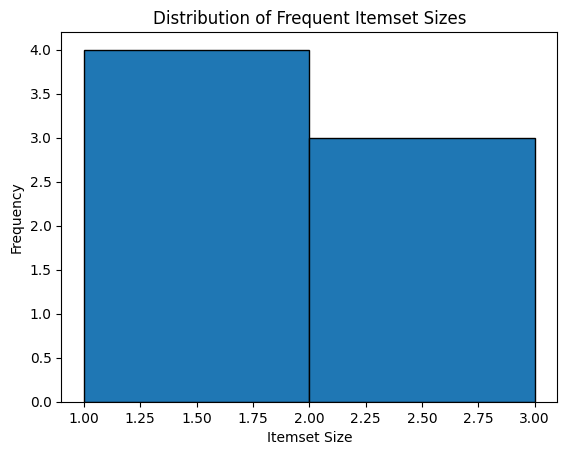

In [14]:
sizes = [len(itemset) for itemset in frequent_itemsets]
plt.hist(sizes, bins=range(1, max(sizes)+2), edgecolor='black')
plt.xlabel('Itemset Size')
plt.ylabel('Frequency')
plt.title('Distribution of Frequent Itemset Sizes')
plt.show()

### **2. Visualize Support Distribution**

- Extracts the support values of all frequent itemsets.
- Plots a histogram to show how support is distributed across itemsets.

**Key idea:**  
- Taller bars → more itemsets have that support value  
- Shorter bars → fewer itemsets have that support value


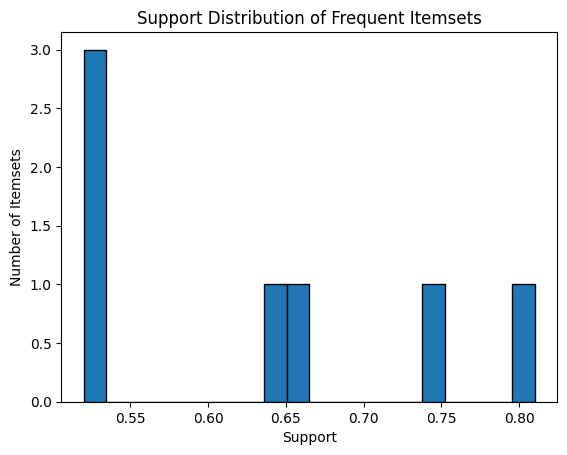

In [ ]:
supports = list(frequent_itemsets.values())
plt.hist(supports, bins=20, edgecolor='black')
plt.xlabel('Support')
plt.ylabel('Number of Itemsets')
plt.title('Support Distribution of Frequent Itemsets')
plt.show()

### **3. Visualize Confidence vs Lift**

- Extracts **confidence** and **lift** from all generated rules.
- Plots a scatter plot with confidence on the x-axis and lift on the y-axis.


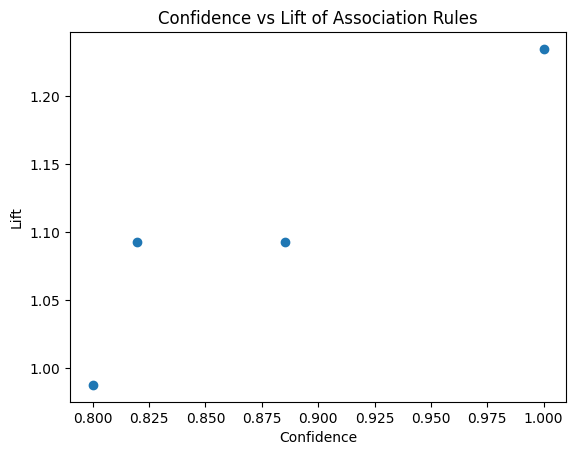

In [ ]:
confidences = [rule[3] for rule in rules]
lifts = [rule[4] for rule in rules]
plt.scatter(confidences, lifts)
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift of Association Rules')
plt.show()

### **Top Association Rules by Lift**

- Sorts all generated rules by **lift** in descending order to find the strongest associations.
- Prints the **antecedent → consequent**, along with support, confidence, and lift.

**Generally:**  
- Higher lift (>1) indicates the rule occurs more often than expected by chance.
- Confidence shows the reliability of the rule.
- Support shows how common the full itemset is in the dataset.


In [ ]:
top_rules = sorted(rules, key=lambda x: x[4], reverse=True)

print("Top Rules by Lift:")
for antecedent, consequent, support_itemset, confidence, lift in top_rules:
    print(f"{set(antecedent)} -> {set(consequent)} | "
          f"support: {support_itemset:.2f}, conf: {confidence:.2f}, lift: {lift:.2f}")


Top Rules by Lift:
{'eggs'} -> {'milk'} | support: 0.53, conf: 1.00, lift: 1.23
{'bread'} -> {'milk'} | support: 0.66, conf: 0.89, lift: 1.09
{'milk'} -> {'bread'} | support: 0.66, conf: 0.82, lift: 1.09
{'sugar'} -> {'milk'} | support: 0.52, conf: 0.80, lift: 0.99
